In [1]:
import numpy as np
from matplotlib import pyplot as plt
from astropy import units as u
from astropy import constants as c
from scipy.integrate import quad
from scipy.interpolate import CubicSpline
from scipy.optimize import curve_fit, fsolve
from tqdm import tqdm

In [2]:
import ROOT as r
import warnings
warnings.filterwarnings('ignore')

In [3]:
r.gSystem.Load('$EVNDISPSYS/lib/libVAnaSum.so')

0

In [4]:
def get_distance(x1, y1, x2, y2):
    square = (x2-x1) ** 2 + (y2-y1) ** 2
    return np.sqrt(square)

In [5]:
def get_impact_factor(xi):

    rel_intensity_per_az = lambda phi, xi: np.sqrt(1 - xi**2 * np.sin(phi)**2)

    if xi > 1:
        bound = np.arcsin(1/xi)
    else:
        bound = np.pi/2
    
    integ = quad(rel_intensity_per_az, 0, bound, args=(xi))[0]
    return integ * 2 / np.pi

In [6]:
#test_xis = np.linspace(0, 4, 10000)
test_xis = np.logspace(-6, 1, 10000)
test_factors = np.zeros_like(test_xis)

for i, xi in enumerate(test_xis):
    test_factors[i] = get_impact_factor(xi)

xi_from_factor = CubicSpline(test_factors[::-1], test_xis[::-1])
xi_from_xi_div_factor = CubicSpline(test_xis / test_factors, test_xis)

In [7]:
# These don't work well on an array -- use the interpolation method (within range)

def solve_factor(y):

    f = lambda xi, factor: get_impact_factor(xi) - factor
    return fsolve(f, x0=1, args=(y))[0]

def solve_xi_div_factor(y):

    f = lambda xi, xi_div_factor: xi / get_impact_factor(xi) - xi_div_factor
    return fsolve(f, x0=1, args=(y))[0]

In [8]:
filename = '/raid/reedbuck/lrizk/veritas/sources/crab_v6/evndisp/muons/110277_muons.root'
real_muons = r.TFile(filename)
params_t1 = real_muons.Get('Tel_1/tpars')
params_t2 = real_muons.Get('Tel_2/tpars')
params_t3 = real_muons.Get('Tel_3/tpars')
params_t4 = real_muons.Get('Tel_4/tpars')

num_events = 0
for event in params_t1:
    if event.muonRadius:
        num_events += 1
for event in params_t2:
    if event.muonRadius:
        num_events += 1
for event in params_t3:
    if event.muonRadius:
        num_events += 1
for event in params_t4:
    if event.muonRadius:
        num_events += 1

real_muon_params = np.zeros((9, num_events))
i = 0

for event in params_t1:
    if event.muonRadius:
        real_muon_params[0][i] = event.muonX0
        real_muon_params[1][i] = event.muonY0
        real_muon_params[2][i] = event.muonXC
        real_muon_params[3][i] = event.muonYC
        real_muon_params[4][i] = event.muonRadius
        real_muon_params[5][i] = event.muonRSigma
        real_muon_params[6][i] = event.muonSize
        real_muon_params[7][i] = event.muonIPCorrectedSize
        real_muon_params[8][i] = event.muonValid
        i += 1
for event in params_t2:
    if event.muonRadius:
        real_muon_params[0][i] = event.muonX0
        real_muon_params[1][i] = event.muonY0
        real_muon_params[2][i] = event.muonXC
        real_muon_params[3][i] = event.muonYC
        real_muon_params[4][i] = event.muonRadius
        real_muon_params[5][i] = event.muonRSigma
        real_muon_params[6][i] = event.muonSize
        real_muon_params[7][i] = event.muonIPCorrectedSize
        real_muon_params[8][i] = event.muonValid
        i += 1
for event in params_t3:
    if event.muonRadius:
        real_muon_params[0][i] = event.muonX0
        real_muon_params[1][i] = event.muonY0
        real_muon_params[2][i] = event.muonXC
        real_muon_params[3][i] = event.muonYC
        real_muon_params[4][i] = event.muonRadius
        real_muon_params[5][i] = event.muonRSigma
        real_muon_params[6][i] = event.muonSize
        real_muon_params[7][i] = event.muonIPCorrectedSize
        real_muon_params[8][i] = event.muonValid
        i += 1
for event in params_t4:
    if event.muonRadius:
        real_muon_params[0][i] = event.muonX0
        real_muon_params[1][i] = event.muonY0
        real_muon_params[2][i] = event.muonXC
        real_muon_params[3][i] = event.muonYC
        real_muon_params[4][i] = event.muonRadius
        real_muon_params[5][i] = event.muonRSigma
        real_muon_params[6][i] = event.muonSize
        real_muon_params[7][i] = event.muonIPCorrectedSize
        real_muon_params[8][i] = event.muonValid
        i += 1

In [9]:
output = 'real_data/muons_110277.csv'
np.savetxt(output, real_muon_params.T, delimiter=',')

In [10]:
csv = 'real_data/muons_110277.csv'
muon_x, muon_y, muon_xc, muon_yc, muon_radii, muon_radii_err, muon_sizes, muon_corr_sizes, muon_valid = np.loadtxt(csv, delimiter=',', unpack=True)

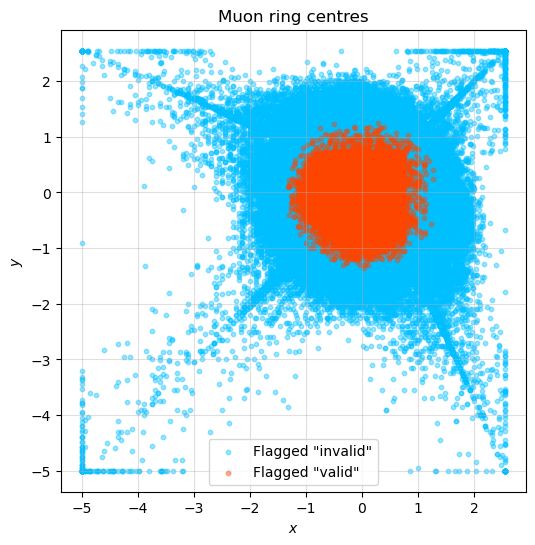

In [11]:
plt.figure(figsize=(6, 6))

validity = np.array([bool(v) for v in muon_valid])

plt.scatter(muon_x[~validity], muon_y[~validity], c='deepskyblue', marker='o', s=10, alpha=0.4, label='Flagged "invalid"')
plt.scatter(muon_x[validity], muon_y[validity], c='orangered', marker='o', s=10, alpha=0.4, label='Flagged "valid"')

# plt.xlim(-4, 4)
# plt.ylim(-4, 4)

plt.grid(alpha=0.4)
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.title('Muon ring centres')
plt.legend()

plt.show()

In [12]:
distances = get_distance(muon_x, muon_y, muon_xc, muon_yc)
evndisp_factors = muon_sizes / muon_corr_sizes
evndisp_xis = xi_from_factor(evndisp_factors)
# validity = np.array([bool(v) for v in muon_valid])

In [13]:
# recalc_xis = xi_from_xi_div_factor(2 * distances / muon_radii)
# recalc_factors = np.zeros_like(recalc_xis)

# for i, xi in enumerate(recalc_xis):
#     recalc_factors[i] = get_impact_factor(xi)

In [14]:
# plt.figure(figsize=(8, 4))

# plt.scatter(evndisp_factors, recalc_factors, c='red', marker='o', s=5)

# plt.xlabel(r'Size $\div$ corrected size')
# plt.ylabel('Recalculated from image centre vs. centroid')
# plt.title('Impact-related factor')

# plt.grid(alpha=0.4)
# plt.show()

In [15]:
# plt.figure(figsize=(8, 4))

# plt.scatter(evndisp_xis, recalc_xis, c='red', marker='o', s=5)

# plt.xlabel(r'Invert $F(\xi)$ from F = size $\div$ corrected size')
# plt.ylabel('Recalculated from image centre vs. centroid')
# plt.title('Normalized impact parameter')

# plt.grid(alpha=0.4)
# plt.show()

In [16]:
# np.max(evndisp_xis[validity]), np.max(recalc_xis)

In [17]:
print("num_valid, num_total")
print(len(muon_x[validity]), len(muon_x))

num_valid, num_total
10316 451797


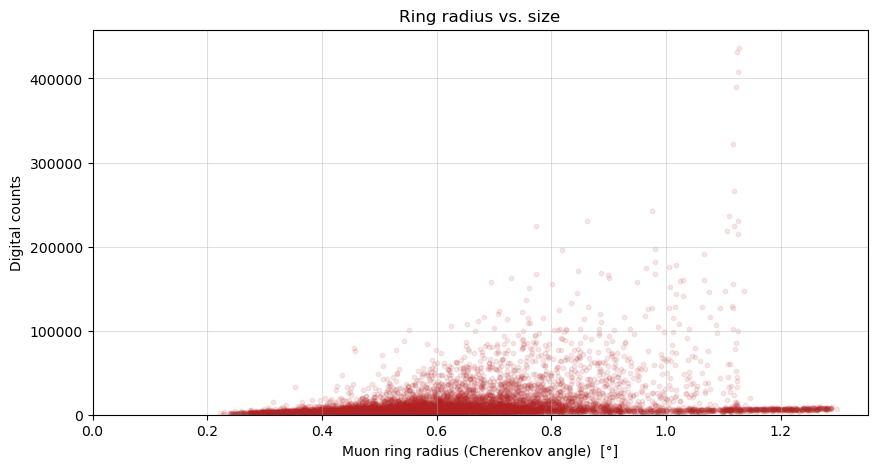

In [18]:
radii = muon_radii[validity]
corr_sizes = muon_corr_sizes[validity]

plt.figure(figsize=(10, 5))

plt.scatter(radii, corr_sizes, c='firebrick', marker='o', s=10, alpha=0.1)

plt.grid(alpha=0.4)
plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel('Digital counts')
plt.title('Ring radius vs. size')

plt.xlim(xmin=0)
plt.ylim(ymin=0)

plt.show()

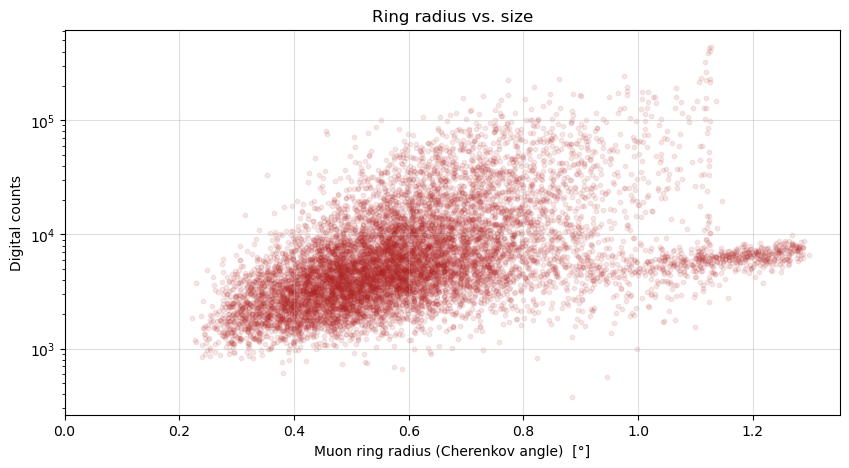

In [19]:
plt.figure(figsize=(10, 5))

plt.scatter(radii, corr_sizes, c='firebrick', marker='o', s=10, alpha=0.1)

plt.grid(alpha=0.4)
plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel('Digital counts')
plt.title('Ring radius vs. size')

plt.xlim(xmin=0)
plt.yscale('log')

plt.show()

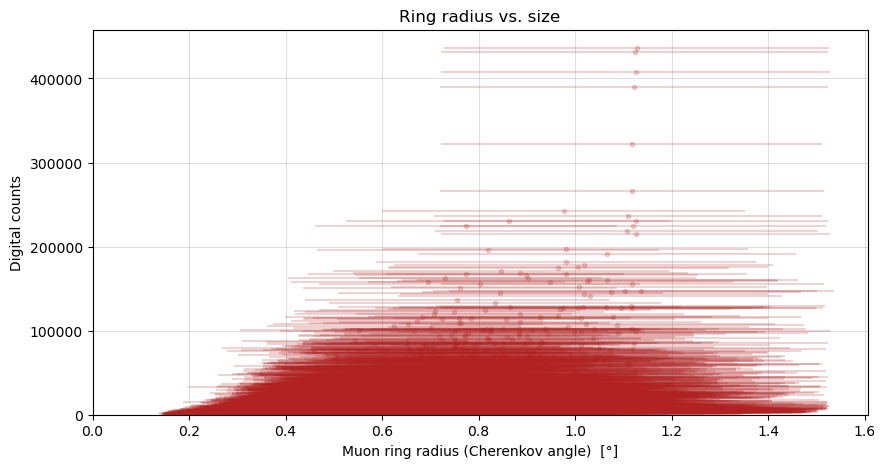

In [20]:
radii_err = muon_radii_err[validity]

plt.figure(figsize=(10, 5))    

plt.errorbar(x=radii, xerr=radii_err, y=corr_sizes, c='firebrick', marker='o', ms=3, ls='', alpha=0.2)

plt.grid(alpha=0.4)
plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel('Digital counts')
plt.title('Ring radius vs. size')

plt.xlim(xmin=0)
plt.ylim(ymin=0)

plt.show()

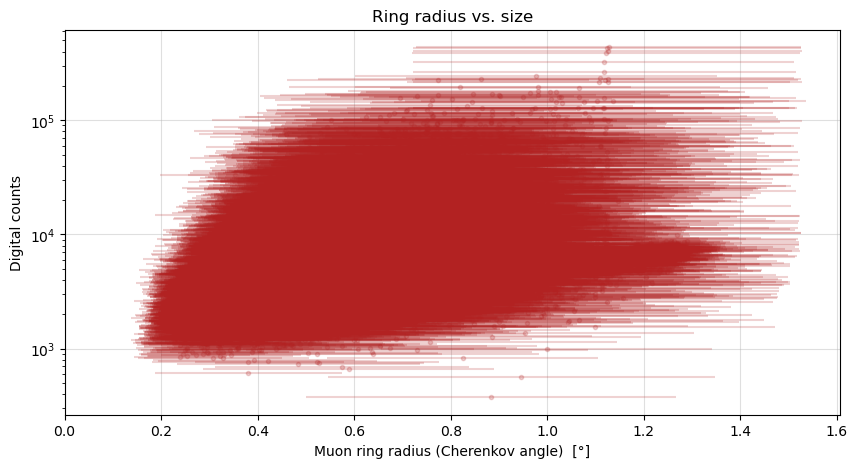

In [21]:
radii_err = muon_radii_err[validity]

plt.figure(figsize=(10, 5))    

plt.errorbar(x=radii, xerr=radii_err, y=corr_sizes, c='firebrick', marker='o', ms=3, ls='', alpha=0.2)

plt.grid(alpha=0.4)
plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel('Digital counts')
plt.title('Ring radius vs. size')

plt.xlim(xmin=0)
plt.yscale('log')

plt.show()

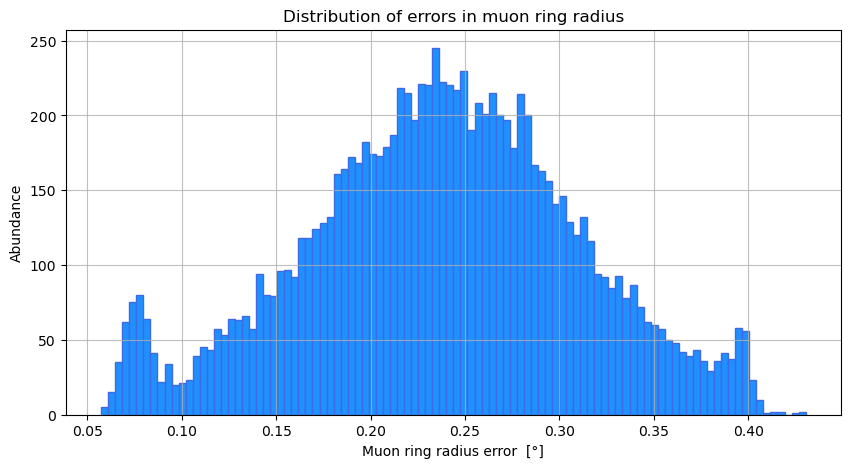

In [22]:
plt.figure(figsize=(10, 5))

hist_data = plt.hist(radii_err, bins=100, edgecolor='royalblue', color='dodgerblue')

plt.grid(alpha=0.8)
plt.xlabel('Muon ring radius error  [°]')
plt.ylabel('Abundance')
plt.title('Distribution of errors in muon ring radius')
plt.show()

In [23]:
err_cutoff = 0.12

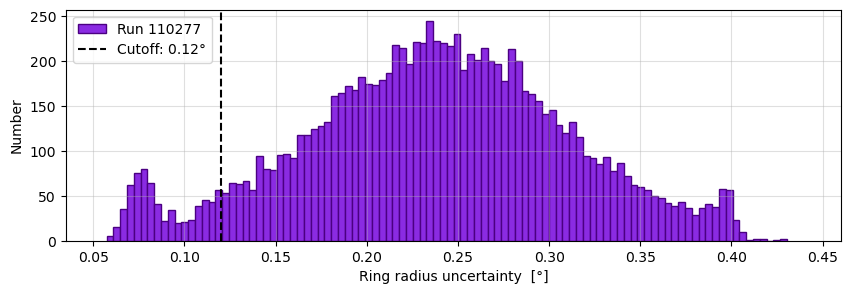

In [24]:
plt.figure(figsize=(10, 3))

hist_data = plt.hist(radii_err, bins=100, edgecolor='indigo', color='blueviolet', label='Run 110277')
plt.axvline(x=err_cutoff, c='black', ls='--', label='Cutoff: 0.12°')

plt.grid(alpha=0.4)
plt.xlabel('Ring radius uncertainty  [°]')
plt.ylabel('Number')
plt.legend(loc='upper left')
plt.xlim(0.035, 0.46)
plt.show()

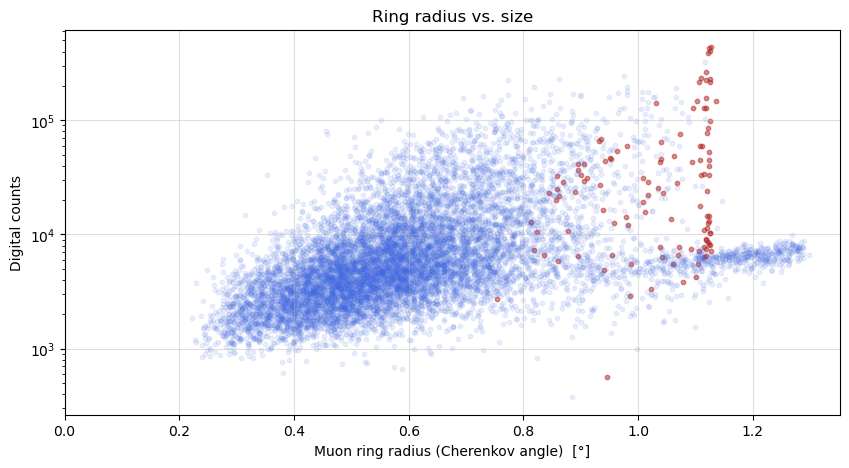

In [25]:
# What is this third population around sigma = 0.4 degrees?

probe = (radii_err >= 0.395) & (radii_err <= 0.405)

probe_radii = radii[probe]
probe_radii_err = radii_err[probe]
probe_corr_sizes = corr_sizes[probe]

not_probe_radii = radii[~probe]
not_probe_radii_err = radii_err[~probe]
not_probe_corr_sizes = corr_sizes[~probe]

plt.figure(figsize=(10, 5))

plt.scatter(probe_radii, probe_corr_sizes, c='firebrick', marker='o', s=10, alpha=0.5)
plt.scatter(not_probe_radii, not_probe_corr_sizes, c='royalblue', marker='o', s=10, alpha=0.1)


plt.grid(alpha=0.4)
plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel('Digital counts')
plt.title('Ring radius vs. size')

plt.xlim(xmin=0)
plt.yscale('log')

plt.show()

In [26]:
np.max(probe_radii)

1.1367146968841553

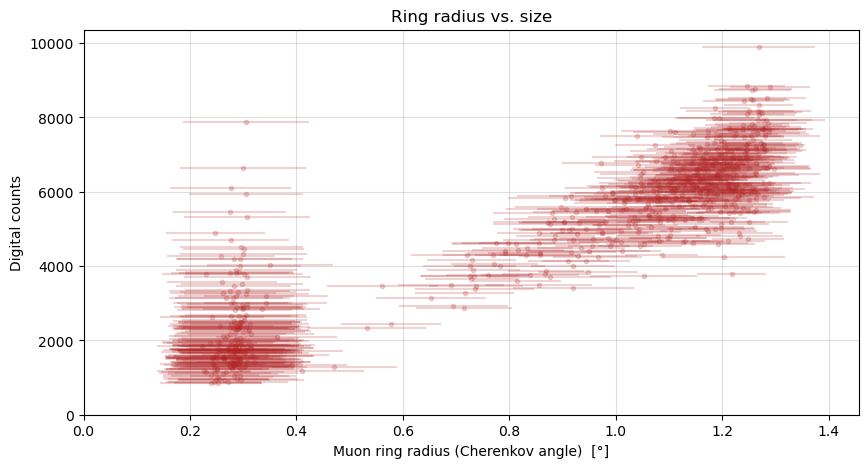

In [25]:
good_radii = radii[radii_err < err_cutoff]
good_radii_err = radii_err[radii_err < err_cutoff]
good_corr_sizes = corr_sizes[radii_err < err_cutoff]

plt.figure(figsize=(10, 5))

plt.errorbar(x=good_radii, xerr=good_radii_err, y=good_corr_sizes, c='firebrick', marker='o', ms=3, ls='', alpha=0.2)

plt.grid(alpha=0.4)
plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel('Digital counts')
plt.title('Ring radius vs. size')

plt.xlim(xmin=0)
plt.ylim(ymin=0)

plt.show()

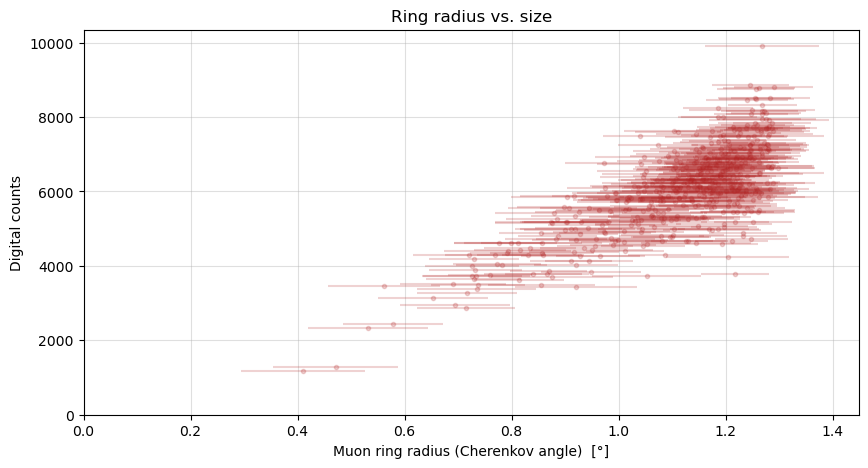

In [26]:
good_radii = radii[(radii_err < err_cutoff) & (radii >= 0.4)]
good_radii_err = radii_err[(radii_err < err_cutoff) & (radii >= 0.4)]
good_corr_sizes = corr_sizes[(radii_err < err_cutoff) & (radii >= 0.4)]

plt.figure(figsize=(10, 5))

plt.errorbar(x=good_radii, xerr=good_radii_err, y=good_corr_sizes, c='firebrick', marker='o', ms=3, ls='', alpha=0.2)

plt.grid(alpha=0.4)
plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel('Digital counts')
plt.title('Ring radius vs. size')

plt.xlim(xmin=0)
plt.ylim(ymin=0)

plt.show()

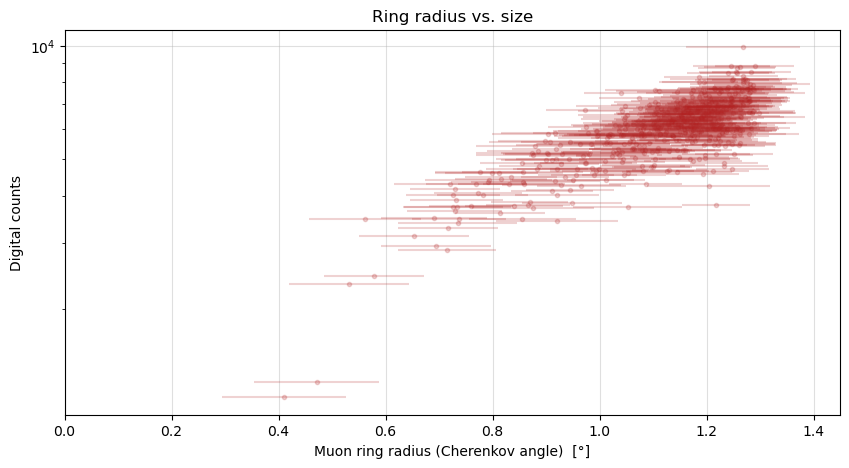

In [27]:
plt.figure(figsize=(10, 5))

plt.errorbar(x=good_radii, xerr=good_radii_err, y=good_corr_sizes, c='firebrick', marker='o', ms=3, ls='', alpha=0.2)

plt.grid(alpha=0.4)
plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel('Digital counts')
plt.title('Ring radius vs. size')

plt.xlim(xmin=0)
plt.yscale('log')

plt.show()

In [28]:
print(len(radii), len(good_radii))

10316 471


In [29]:
def linear_0(y, a):

    a_prime = 1/a
    
    return a_prime * y

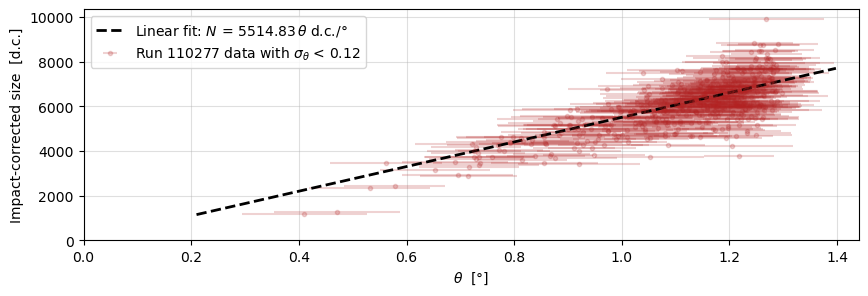

In [30]:
fit_0 = curve_fit(
linear_0,
xdata=good_corr_sizes, 
ydata=good_radii,
sigma=good_radii_err,
absolute_sigma=True, 
p0=[5000],
)

slope_0 = fit_0[0][0]
angles_range = np.linspace(np.min(good_radii) - 0.2, np.max(good_radii) + 0.1, 1000)

plt.figure(figsize=(10, 3))


plt.errorbar(x=good_radii, xerr=good_radii_err, y=good_corr_sizes, c='firebrick', marker='o', ms=3, ls='', alpha=0.2,
             label=r'Run 110277 data with $\sigma_\theta$ < {}'.format(round(err_cutoff, 2)))
plt.plot(angles_range, slope_0 * angles_range, c='black', lw=2, ls='--',
         label=r'Linear fit: $N \, = \, {} \, \theta$ d.c./°'.format(round(slope_0, 2)))

plt.grid(alpha=0.4)
plt.xlabel(r'$\theta$  [°]')
plt.ylabel('Impact-corrected size  [d.c.]')
plt.legend()

plt.xlim(0, 1.44)
plt.ylim(ymin=0)

plt.show()

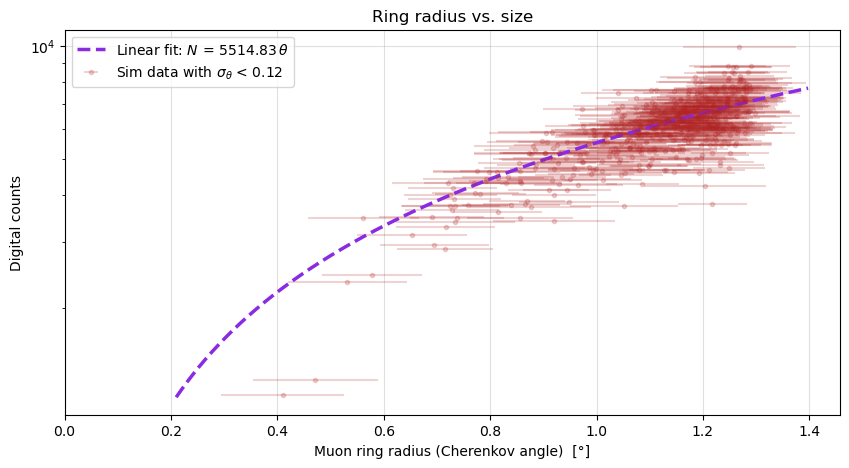

In [31]:
fit_0 = curve_fit(
linear_0,
xdata=good_corr_sizes, 
ydata=good_radii,
sigma=good_radii_err,
absolute_sigma=True, 
p0=[5000],
)

slope_0 = fit_0[0][0]
angles_range = np.linspace(np.min(good_radii) - 0.2, np.max(good_radii) + 0.1, 1000)

plt.figure(figsize=(10, 5))


plt.errorbar(x=good_radii, xerr=good_radii_err, y=good_corr_sizes, c='firebrick', marker='o', ms=3, ls='', alpha=0.2,
             label=r'Sim data with $\sigma_\theta$ < {}'.format(round(err_cutoff, 2)))
plt.plot(angles_range, slope_0 * angles_range, c='blueviolet', lw=2.5, ls='--',
         label=r'Linear fit: $N \, = \, {} \, \theta$'.format(round(slope_0, 2)))

plt.grid(alpha=0.4)
plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel('Digital counts')
plt.legend()
plt.title('Ring radius vs. size')

plt.xlim(xmin=0)
plt.yscale('log')

plt.show()

In [32]:
model_guesses_0 = linear_0(good_corr_sizes, slope_0)

chi2 = np.sum((model_guesses_0 - good_radii)**2 / (good_radii_err)**2)
dof = len(model_guesses_0) - 1
red_chi2 = chi2/dof
print('Reduced chi^2:', red_chi2)

Reduced chi^2: 3.45858260315819


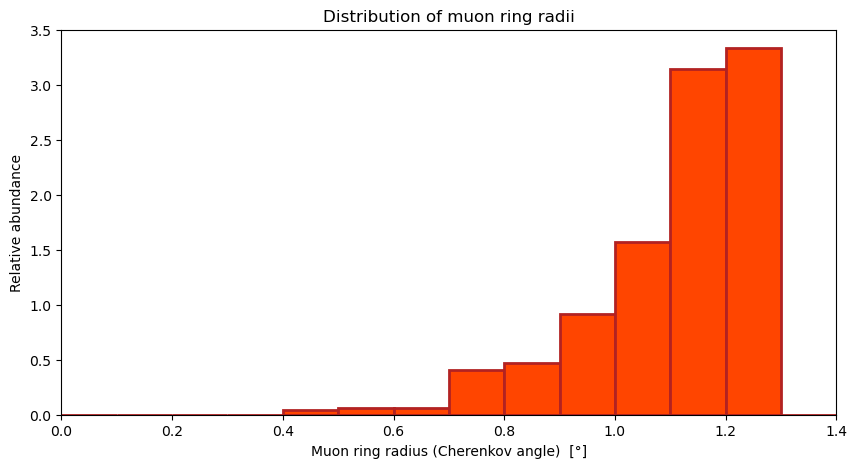

In [33]:
histobins = np.arange(0, 1.5, 0.1)

plt.figure(figsize=(10, 5))

plt.hist(good_radii, bins=histobins, density=True, edgecolor='firebrick', lw=2, color='orangered')
plt.xlim(histobins[0], histobins[-1])

plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel('Relative abundance')
plt.title('Distribution of muon ring radii')
plt.show()

In [34]:
muon_mass = (105.65837 * u.MeV/c.c**2).to(u.kg).value  # kg
veritas_alt = 1268  # m
optimal_wvl = 380*1e-9

def n_air(lam, alt=veritas_alt):

    # Empirically determined constants
    A = 2.73e-4 
    B = 1.23e-18  # m^2
    C = 3.56e-32  # m^4
    
    # Scale height of the atmosphere
    h_0 = 8.4e3  # m

    epsilon_0 = A + B/lam**2 + C/lam**4
    epsilon = epsilon_0 * np.exp(-alt / h_0)
    
    return 1 + epsilon

def get_beta(E, m=c.m_e.value):

    return np.sqrt(1 - m**2 * c.c.value**4 / E**2)

def get_cherenkov_angle(beta, n):

    return np.arccos(1 / (beta * n))

def dNdtheta(theta, N_tot, E_min, E_max, index, n, m):

    a = N_tot * (index+1) / (E_max**(index+1) - E_min**(index+1))

    A = a * (m * c.c.value**2) ** (index+1)
    B = (1 - n**-2 * np.cos(theta)**-2) ** (-0.5*index - 1.5)
    C = np.tan(theta) * n**-2 * np.cos(theta)**-2

    return A * B * C

E_min = 5.3 * u.GeV.to(u.J)  # J
E_max = 1e4 * u.GeV.to(u.J)  # J
index = -2.7

reference_n = n_air(optimal_wvl)
asymptotic_theta = get_cherenkov_angle(beta=1, n=reference_n)
sample_thetas = np.linspace(
    get_cherenkov_angle(beta=get_beta(E_min, m=muon_mass), n=reference_n),
    get_cherenkov_angle(beta=get_beta(E_max, m=muon_mass), n=reference_n),
    10000
)

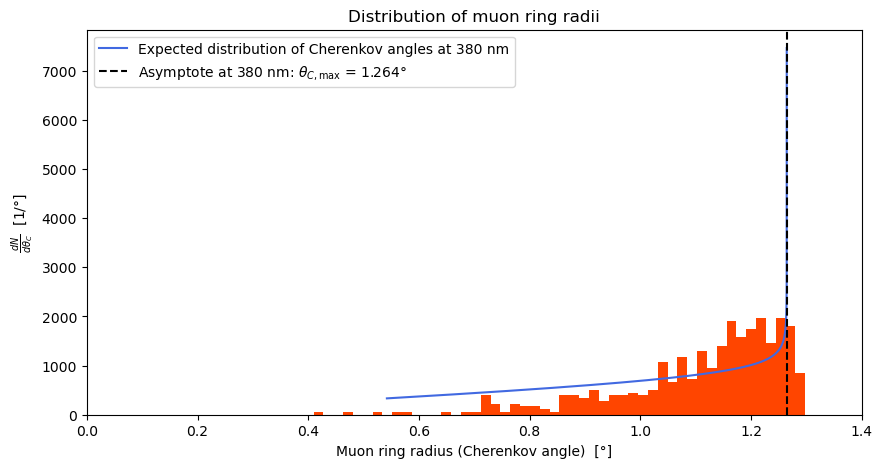

In [35]:
N_tot = len(good_radii)
histo_values, bin_edges = np.histogram(good_radii, bins=50, density=True)

plt.figure(figsize=(10, 5))

plt.stairs(histo_values * N_tot, bin_edges, fill=True, color='orangered')  # Area of all bins = N_tot

plt.plot(sample_thetas / np.pi * 180, 
         dNdtheta(sample_thetas, N_tot, E_min, E_max, index, n=reference_n, m=muon_mass) 
         * np.pi / 180,
         c='royalblue', lw=1.5,
         label='Expected distribution of Cherenkov angles at {} nm'.format(int(optimal_wvl * 1e9)))

plt.axvline(asymptotic_theta / np.pi * 180, 
            label='Asymptote at {} nm: '.format(int(optimal_wvl * 1e9))
            + r'$\theta_{C, \mathrm{max}}$ = ' 
            + str(round(asymptotic_theta / np.pi * 180, 3)) + '°',
            c='black', lw=1.5, ls='--')

plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel(r'$\frac{dN}{d\theta_C}$  [1/°]')
plt.title('Distribution of muon ring radii')

plt.xlim(histobins[0], histobins[-1])
plt.legend()

plt.show()

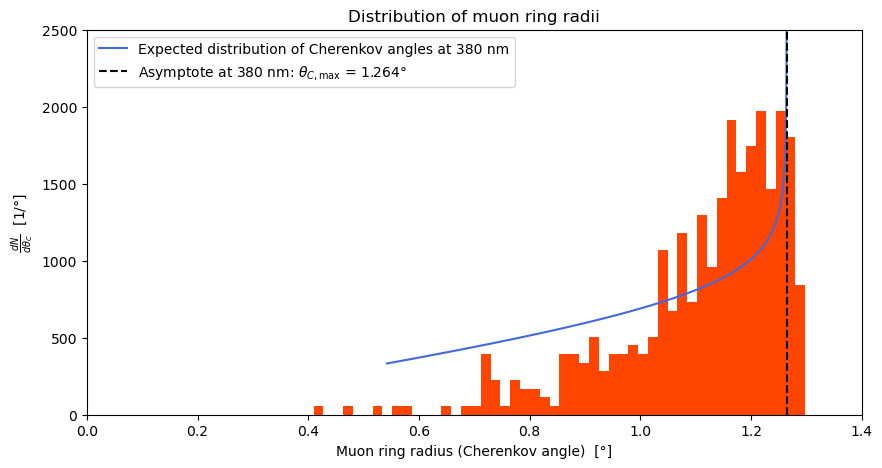

In [36]:
plt.figure(figsize=(10, 5))

plt.stairs(histo_values * N_tot, bin_edges, fill=True, color='orangered')  # Area of all bins = N_tot

plt.plot(sample_thetas / np.pi * 180, 
         dNdtheta(sample_thetas, N_tot, E_min, E_max, index, n=reference_n, m=muon_mass) 
         * np.pi / 180,
         c='royalblue', lw=1.5,
         label='Expected distribution of Cherenkov angles at {} nm'.format(int(optimal_wvl * 1e9)))

plt.axvline(asymptotic_theta / np.pi * 180, 
            label='Asymptote at {} nm: '.format(int(optimal_wvl * 1e9))
            + r'$\theta_{C, \mathrm{max}}$ = ' 
            + str(round(asymptotic_theta / np.pi * 180, 3)) + '°',
            c='black', lw=1.5, ls='--')

plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel(r'$\frac{dN}{d\theta_C}$  [1/°]')
plt.title('Distribution of muon ring radii')

plt.xlim(histobins[0], histobins[-1])
plt.ylim(0, 2500)
plt.legend()

plt.show()

In [37]:
# def dNdxi(xi, N_tot, xi_max):
#     return N_tot / xi_max**2 * (2 * xi)

# xi_max = 3

In [38]:
# plt.figure(figsize=(10, 5))

# histo_values, bin_edges = np.histogram(recalc_xis, bins=60, density=False)
# plt.stairs(histo_values, bin_edges, fill=True, color='orangered')

# plt.xlabel(r'Normalized impact parameter ($\xi$)')
# plt.ylabel(r'$N$')
# plt.title('Distribution of impact parameters (all)')

# plt.show()

In [39]:
sizes = muon_sizes[validity]
good_sizes = sizes[(radii_err < err_cutoff) & (radii >= 0.4)]
evndisp_factors = good_sizes / good_corr_sizes
evndisp_xis = xi_from_factor(evndisp_factors)

In [40]:
valid_distances = distances[validity]
good_distances = valid_distances[(radii_err < err_cutoff) & (radii >= 0.4)]

recalc_xis = xi_from_xi_div_factor(2 * good_distances / good_radii)
recalc_factors = np.zeros_like(recalc_xis)

for i, xi in enumerate(recalc_xis):
    recalc_factors[i] = get_impact_factor(xi)

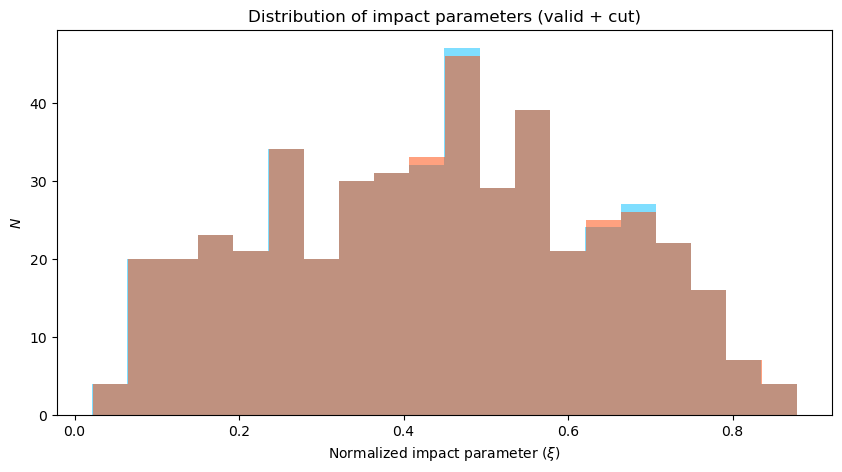

In [41]:
plt.figure(figsize=(10, 5))

histo_values, bin_edges = np.histogram(recalc_xis, bins=20, density=False)
plt.stairs(histo_values, bin_edges, fill=True, color='deepskyblue', alpha=0.5)
plt.hist(evndisp_xis, bins=20, color='orangered', alpha=0.5)

plt.xlabel(r'Normalized impact parameter ($\xi$)')
plt.ylabel(r'$N$')
plt.title('Distribution of impact parameters (valid + cut)')

plt.show()

In [42]:
len(recalc_xis), len(evndisp_xis)

(471, 471)

In [43]:
# plt.figure(figsize=(10, 5))

# centre_dists = (muon_x**2 + muon_y**2)**0.5
# plt.hist(centre_dists, bins=20, color='firebrick')

# plt.xlabel(r'Distance of ring centre from centre of camera plane ($\xi$)')
# plt.ylabel(r'$N$')
# plt.title('Distribution of angle offsets (all)')

# plt.show()

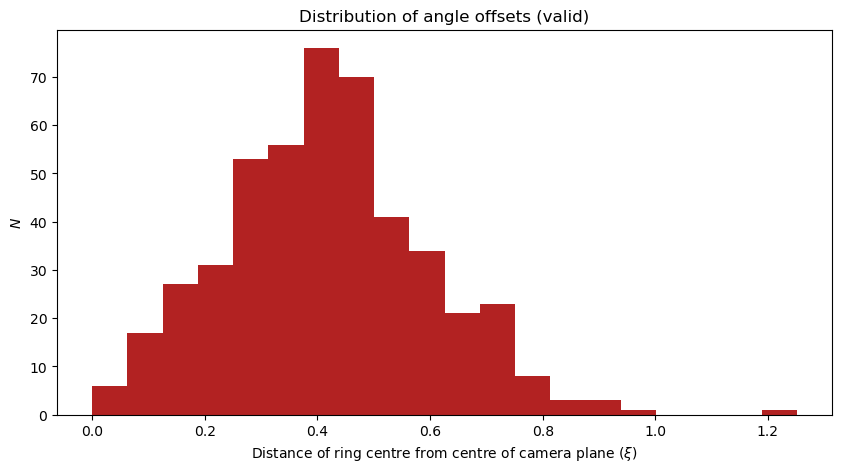

In [44]:
centre_dists = (muon_x**2 + muon_y**2)**0.5
valid_centre_dists = centre_dists[validity]
good_centre_dists = valid_centre_dists[(radii_err < err_cutoff) & (radii >= 0.4)]

plt.figure(figsize=(10, 5))

plt.hist(good_centre_dists, bins=20, color='firebrick')

plt.xlabel(r'Distance of ring centre from centre of camera plane ($\xi$)')
plt.ylabel(r'$N$')
plt.title('Distribution of angle offsets (valid)')

plt.show()